# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 





### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

## 1. Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [272]:
### 1. Setup *env and start logger 

%load_ext dotenv
%dotenv
import os, sys
sys.path.append(os.getenv('SRC_DIR'))

# start logger 
from utils.logger import get_logger
_logs = get_logger(__name__)

from datetime import datetime
now = datetime.now()
formatted_date_weekday = now.strftime("%A, %B %d, %Y")
_logs.info(f"Hello! Welcome to Python's World 🐍🐍~! Today is {datetime.now().strftime('%A, %B %d, %Y')}")

2025-10-08 18:08:31,328, 2027132908.py, 15, INFO, Hello! Welcome to Python's World 🐍🐍~! Today is Wednesday, October 08, 2025


The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [273]:
### 2. Load the libraries as required.

import pandas as pd
import numpy as np

## library 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder

# from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import BaggingRegressor

## evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, max_error, make_scorer

## for plot
import matplotlib.pyplot as plt
import seaborn as sns

# utilities 
import time


In [274]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()

# check if contains any na
has_na = fires_dt.isna().any().any()
print(f"Does data contains any NA: {has_na}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
Does data contains any NA: False


## 2. Get X and Y

Create the features data frame and target data.

In [275]:
# quick exame
fires_dt.describe()

,coord_x,coord_y,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [276]:
fires_dt['coord_x'].values

array([7, 7, 7, 8, 8, 8, 8, 8, 8, 7, 7, 7, 6, 6, 6, 6, 5, 8, 6, 6, 6, 5,
       7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 4, 4, 4, 4, 4,
       4, 5, 5, 6, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 4, 4, 4, 5, 5, 5, 9, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 6, 6, 8, 8, 8, 8, 4, 3, 3, 3, 3, 3, 3, 2, 2, 2, 4, 4, 4, 4, 4,
       4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 4, 4,
       4, 4, 3, 3, 3, 3, 9, 1, 2, 1, 8, 1, 2, 6, 5, 8, 2, 8, 6, 9, 3, 5,
       1, 7, 2, 2, 2, 7, 7, 6, 6, 8, 8, 6, 6, 6, 6, 8, 5, 8, 7, 4, 1, 1,
       6, 2, 2, 8, 1, 8, 5, 7, 8, 2, 8, 1, 6, 7, 6, 2, 2, 4, 2, 2, 6, 4,
       3, 2, 1, 6, 7, 8, 5, 4, 2, 7, 6, 8, 4, 7, 7, 7, 4, 4, 4, 1, 4, 6,
       8, 3, 4, 2, 7, 4, 7, 8, 4, 8, 4, 1, 6, 9, 4, 8, 2, 1, 6, 7, 6, 4,
       2, 7, 2, 3, 5, 2, 8, 3, 8, 8, 6, 7, 6, 2, 8, 4, 3, 7, 2, 3, 2, 6,
       4, 4, 6, 2, 3, 4, 2, 8, 2, 4, 8, 4, 4, 3, 4, 4, 4, 6, 6, 3, 5, 2,
       7, 7, 7, 7, 2, 9, 4, 7, 8, 7, 6, 8, 8, 6, 6,

In [277]:
# target data
y = fires_dt['area']

# feature data
x = fires_dt.drop(columns='area')


In [278]:
# working on convar = continous variables
convar_df = fires_dt.select_dtypes(exclude='object') # remove categorical variabels 
convar_df = convar_df.drop(columns = ['coord_x','coord_y'])
convar_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ffmc    517 non-null    float64
 1   dmc     517 non-null    float64
 2   dc      517 non-null    float64
 3   isi     517 non-null    float64
 4   temp    517 non-null    float64
 5   rh      517 non-null    int64  
 6   wind    517 non-null    float64
 7   rain    517 non-null    float64
 8   area    517 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 36.5 KB


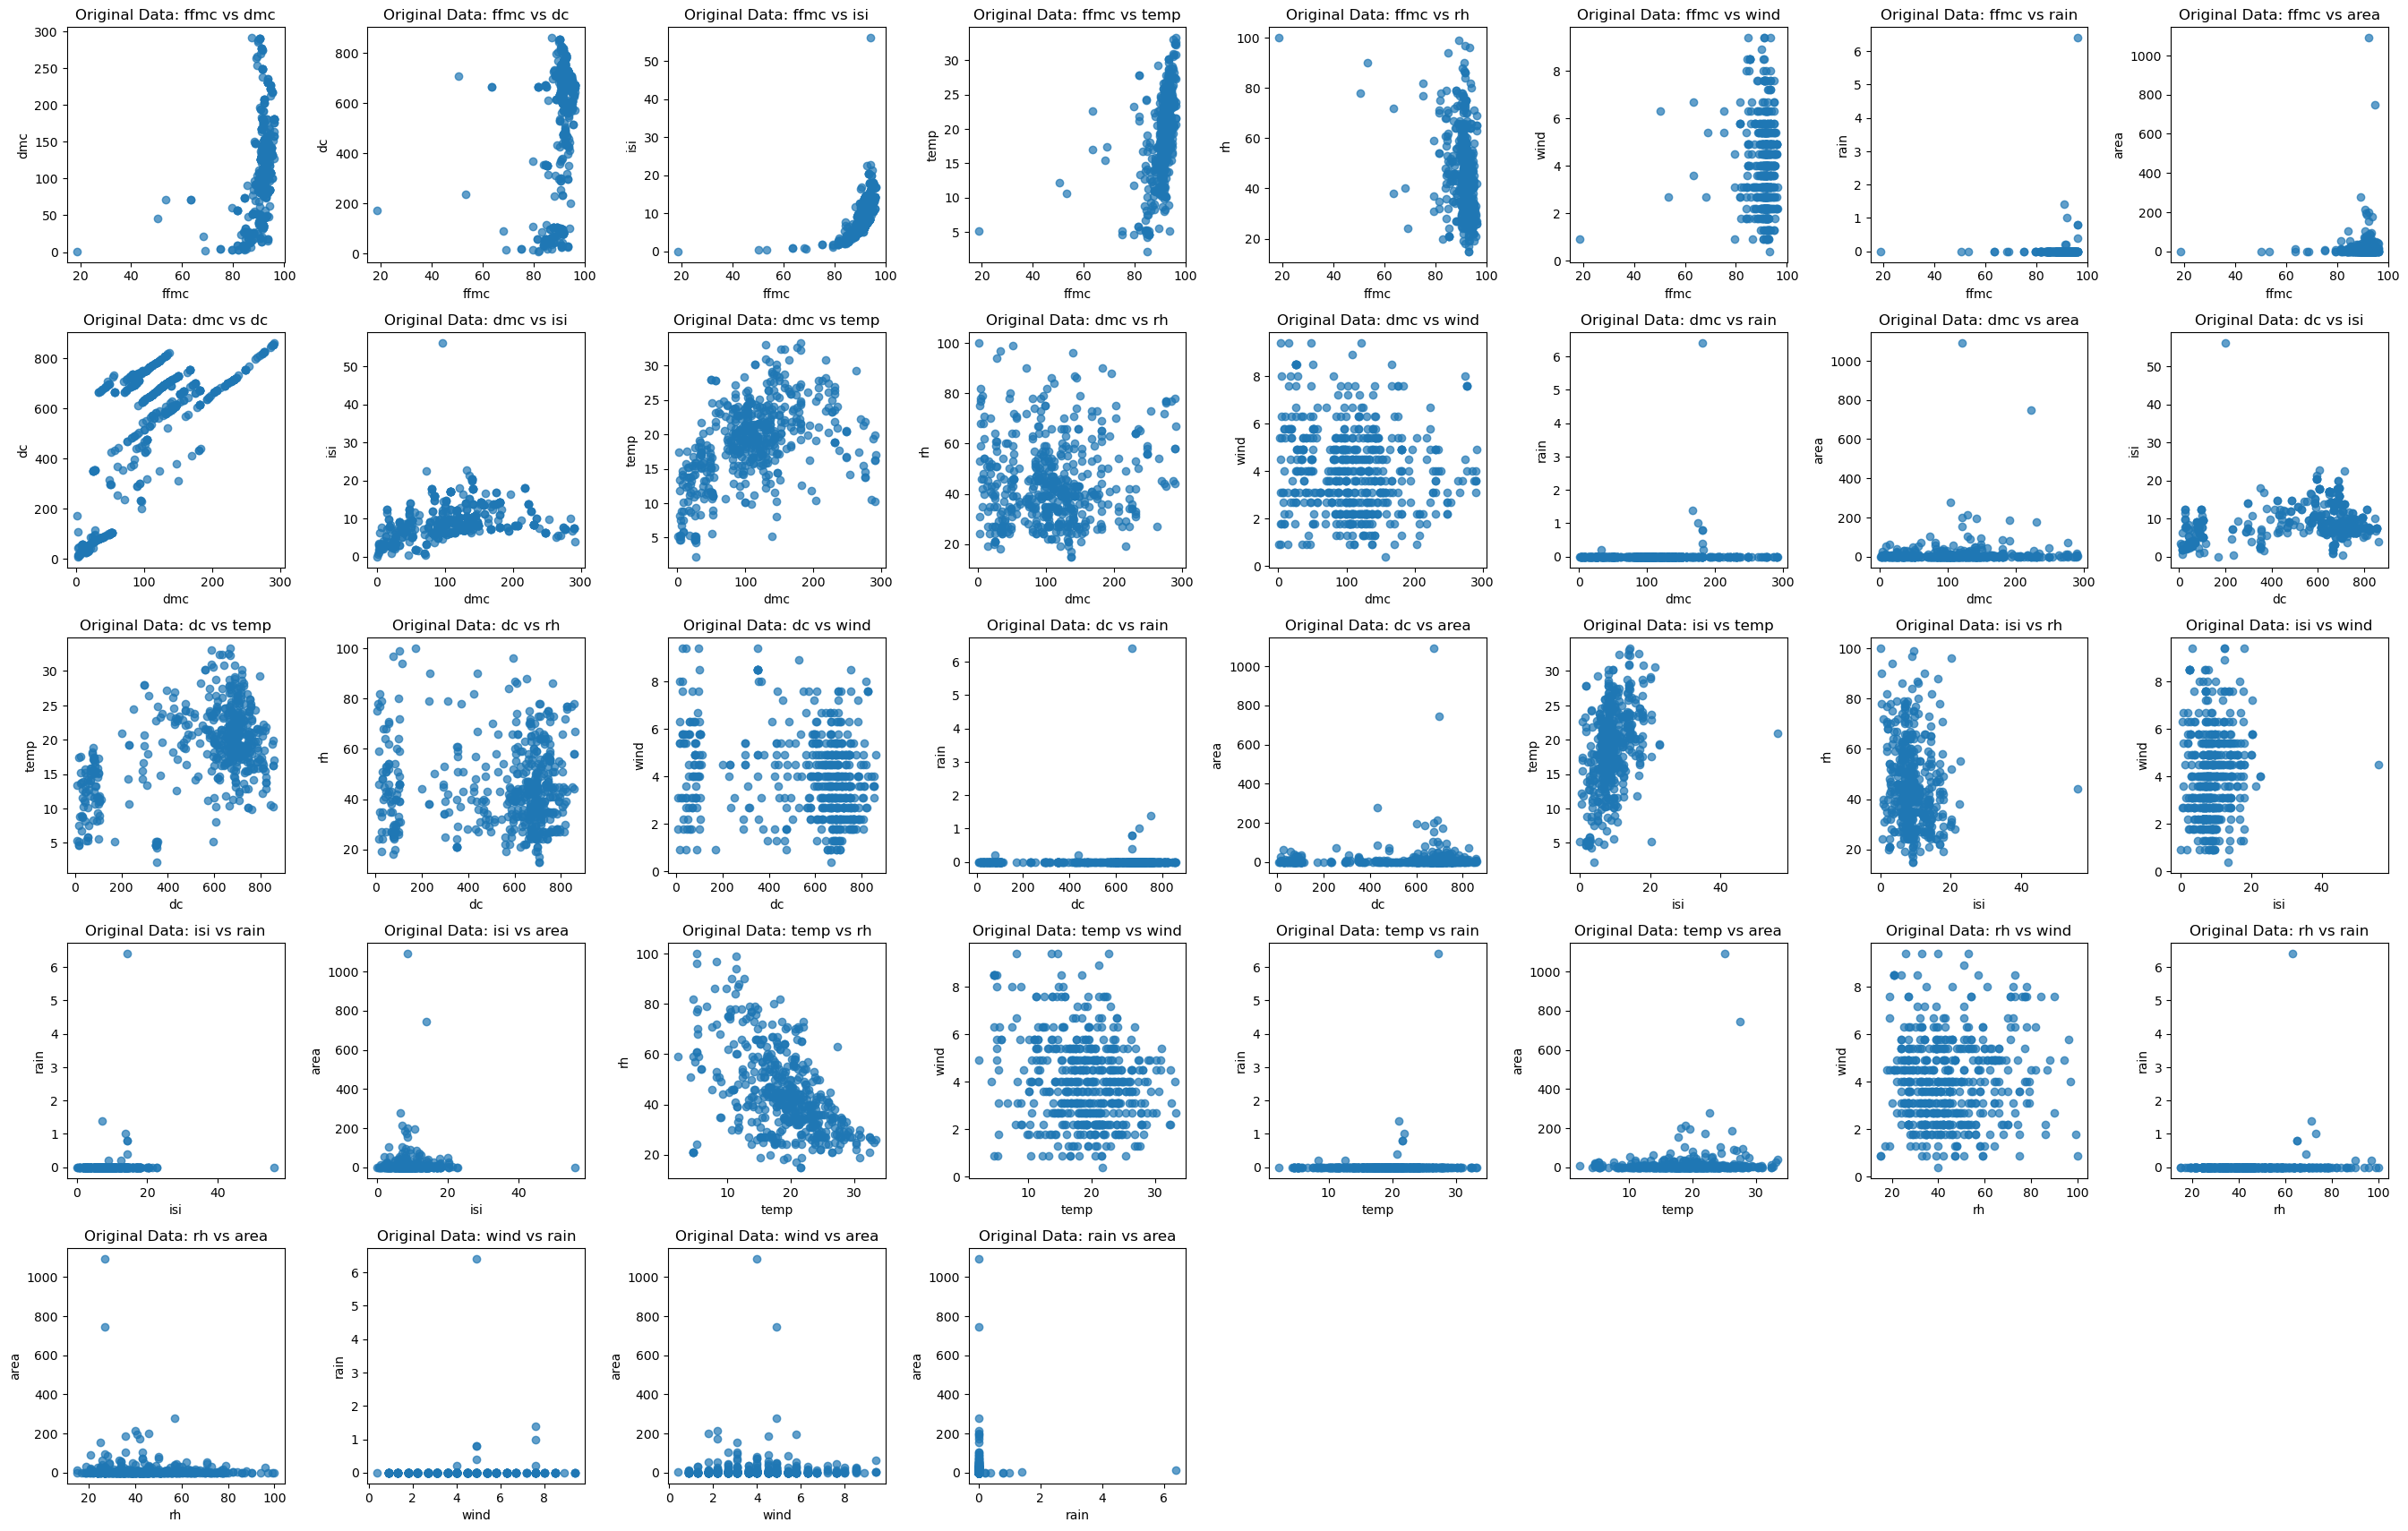

In [279]:
### 3. Plot to exam the data (recycle the code from LCR) 😊😊

def plot_feature_pairs(data, feature_names, color_labels=None, title_prefix=''):
    """
    Helper function to create scatter plots for all possible pairs of features.
    
    Parameters:
    - data: DataFrame containing the features to be plotted.
    - feature_names: List of feature names to be used in plotting.
    - color_labels: Optional. Cluster or class labels to color the scatter plots.
    - title_prefix: Optional. Prefix for plot titles to distinguish between different sets of plots.
    """
    # Create a figure for the scatter plots
    plt.figure(figsize=(3*len(feature_names), 3*len(feature_names)))
    
    # Counter for subplot index
    plot_number = 1
    
    # Loop through each pair of features
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            plt.subplot(len(feature_names)-1, len(feature_names)-1, plot_number)
            
            # Scatter plot colored by labels if provided
            if color_labels is not None:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], 
                            c=color_labels, cmap='viridis', alpha=0.7)
            else:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], alpha=0.7)
            
            plt.xlabel(feature_names[i])
            plt.ylabel(feature_names[j])
            plt.title(f'{title_prefix}{feature_names[i]} vs {feature_names[j]}')
            
            # Increment the plot number
            plot_number += 1

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # save the plot
    plt.savefig("scatter_grid.png", dpi=300)  # dpi=300 for high quality

    # Show the plot
    plt.show()

# Get feature names
feature_names = convar_df.columns

# Use the helper function to plot scatter plots without coloring by cluster labels
plot_feature_pairs(convar_df, feature_names, title_prefix='Original Data: ')


In [280]:
feature_names

Index(['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area'], dtype='object')

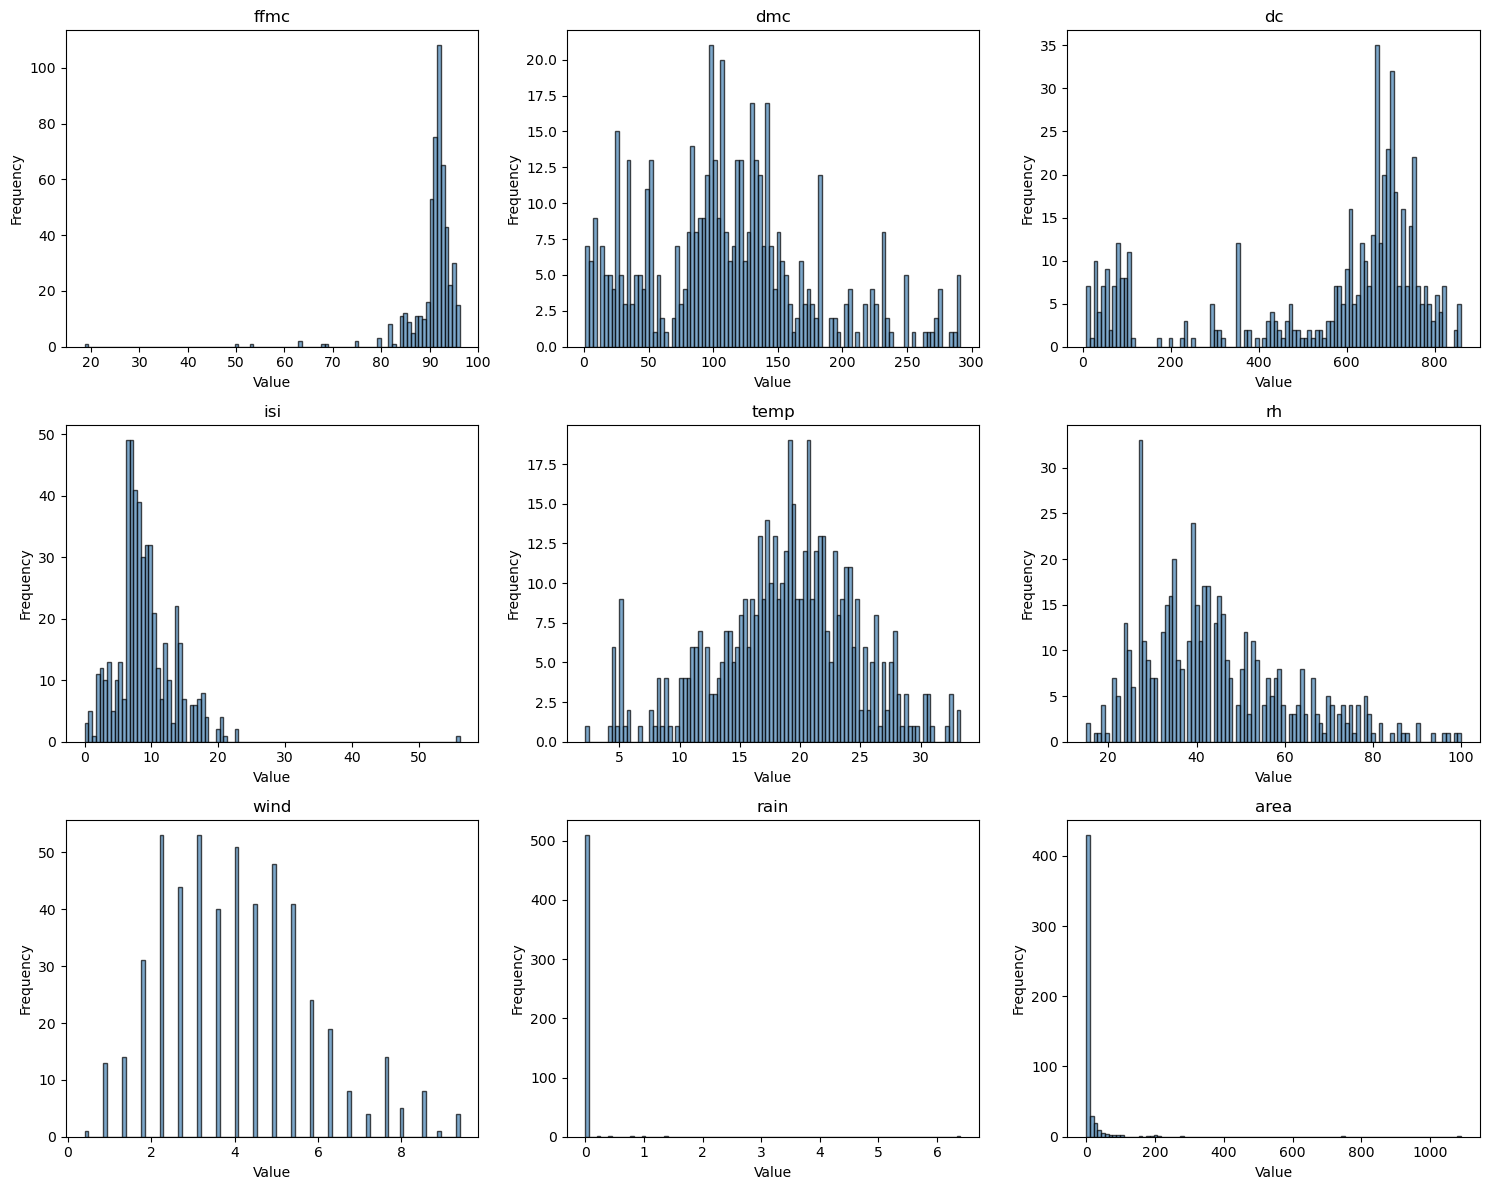

In [281]:
### plot the histogram for all the numeric values:

cols = convar_df.columns
n_cols = 3  # number of columns in the grid
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(convar_df[col], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
    plt.title(col)
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()



In [282]:
## use VIF to check for Multicolineariry (Use code from LCR module)
# install VIF
!pip install statsmodels


In [283]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = feature_names
vif_data["VIF"] = [variance_inflation_factor(convar_df.values,i) for i in range (convar_df.shape[1])] 
vif_data.sort_values(by='VIF',ascending=False)

,feature,VIF
0,ffmc,54.405193
4,temp,28.214129
2,dc,12.227811
5,rh,11.772193
1,dmc,8.548452
6,wind,6.647500
3,isi,6.420681
8,area,1.057746
7,rain,1.037971


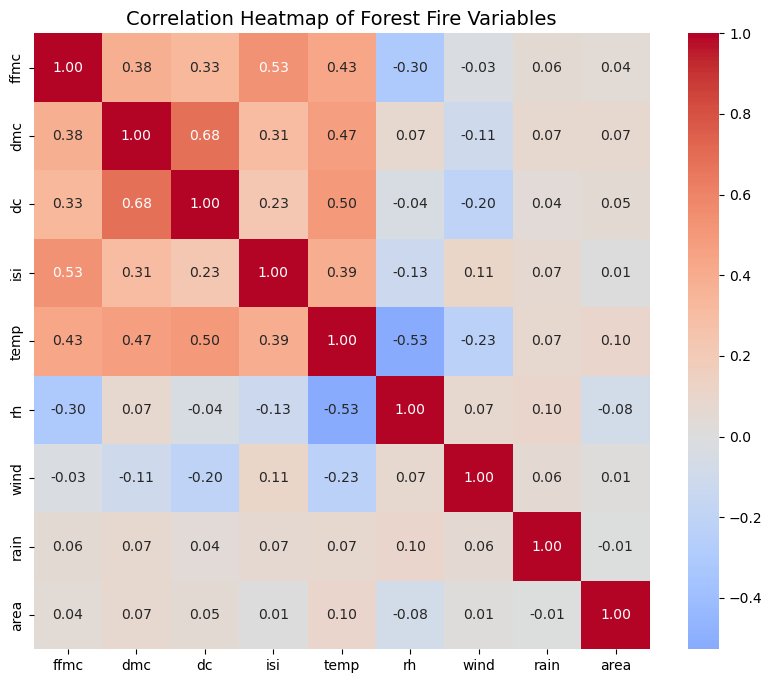

In [284]:
## check for correlation matrix 
import seaborn as sns

# Compute correlation matrix
corr_matrix = convar_df.corr()

# Set up the figure
plt.figure(figsize=(10, 8))

# Draw heatmap with color scale and annotations
sns.heatmap(
    corr_matrix,
    annot=True,         # show correlation values
    fmt=".2f",
    cmap="coolwarm",    # color scheme: blue (-1) to red (+1)
    center=0,
    square=True
)
plt.title("Correlation Heatmap of Forest Fire Variables", fontsize=14)
plt.show()


### ![BONUS-BLUE](https://img.shields.io/badge/BONUS-496C9C?style=for-the-badge) Summary from a quick data observation

1. Some observation of **skewness** of data points
    - normal skewness: ffmc, dc, isi, rh
    - **extreme skewness: rain**  
2. Extreme high **multicollinearity** (VIF>20):ffmc (Fine Fuel Moisture Code), temp
    - ffmc : isi
    - temp : rh
3. High **multicollinearity** (VIF>10): dc( Drought Code), rh(Relative Humidity (%))
    - dc : dmc & temp 


## 3. Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [285]:
## Set random_state for both train_test_split and pipeline

seed1 = 9   # for pipeline 
seed2 = 891 # for train_test split


In [286]:
## Preproc 1

num_x = convar_df.drop(columns=['area']).columns
display(num_x)
cat_x = x.columns.difference(num_x)
display(cat_x)

Prepoc1 = ColumnTransformer(
    transformers=[
        ('std_scaler', StandardScaler(), num_x ),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist'), cat_x), 
    ], remainder='drop' # can also use 'pass through"  or "raise an error"
)
Prepoc1


Index(['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain'], dtype='object')

Index(['coord_x', 'coord_y', 'day', 'month'], dtype='object')

ColumnTransformer(transformers=[('std_scaler', StandardScaler(),
                                 Index(['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain'], dtype='object')),
                                ('onehot',
                                 OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                 Index(['coord_x', 'coord_y', 'day', 'month'], dtype='object'))])

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [287]:
## Preproc 2

skew_num_x =['ffmc', 'dc', 'isi', 'rh', 'rain']
type(skew_num_x)
nor_num_x = num_x.difference(skew_num_x)
nor_num_x

Prepoc2 = ColumnTransformer(
    transformers=[
        ('std_scaler', StandardScaler(), num_x ),
        ('num_yj', PowerTransformer(method='yeo-johnson'),skew_num_x),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist'), cat_x), 
    ], remainder='drop' # can also use 'pass through"  or "raise an error"
)
Prepoc2

ColumnTransformer(transformers=[('std_scaler', StandardScaler(),
                                 Index(['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain'], dtype='object')),
                                ('num_yj', PowerTransformer(),
                                 ['ffmc', 'dc', 'isi', 'rh', 'rain']),
                                ('onehot',
                                 OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                 Index(['coord_x', 'coord_y', 'day', 'month'], dtype='object'))])

## 4. Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [288]:
# Pipeline A = preproc1 + baseline

Prepoc1 = ColumnTransformer(
    transformers=[
        ('std_scaler', StandardScaler(), num_x ),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist'), cat_x), 
    ], remainder='drop' # can also use 'pass through"  or "raise an error"
)
Prepoc1
pipe_a = Pipeline([
        ('preproc', Prepoc1),
        ('pca', PCA()), 
        ('knn',KNeighborsRegressor())   # KNN regressor does not need to set random seed 
        ])
pipe_a


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('std_scaler',
                                                  StandardScaler(),
                                                  Index(['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain'], dtype='object')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  Index(['coord_x', 'coord_y', 'day', 'month'], dtype='object'))])),
                ('pca', PCA()), ('knn', KNeighborsRegressor())])

In [289]:
# Pipeline B = preproc2 + baseline

Prepoc2 = ColumnTransformer(
    transformers=[
        ('std_scaler', StandardScaler(), num_x ),
        ('num_yj', PowerTransformer(method='yeo-johnson'),skew_num_x),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist'), cat_x), 
    ], remainder='drop' # can also use 'pass through"  or "raise an error"
)
Prepoc2
pipe_b = Pipeline([
        ('preproc', Prepoc2), 
        ('tree', DecisionTreeRegressor(random_state=seed1))
    ])
pipe_b

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('std_scaler',
                                                  StandardScaler(),
                                                  Index(['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain'], dtype='object')),
                                                 ('num_yj', PowerTransformer(),
                                                  ['ffmc', 'dc', 'isi', 'rh',
                                                   'rain']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  Index(['coord_x', 'coord_y', 'day', 'month'], dtype='object'))])),
                ('tree', DecisionTreeRegressor(random_state=9))])

In [290]:
# Pipeline C = preproc1 + advanced model (bagging)

Prepoc1 = ColumnTransformer(
    transformers=[
        ('std_scaler', StandardScaler(), num_x ),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist'), cat_x), 
    ], remainder='drop' # can also use 'pass through"  or "raise an error"
)
Prepoc1
pipe_c = Pipeline([
        ('preproc', Prepoc1),
        ('bagging', BaggingRegressor(
             estimator=DecisionTreeRegressor(),
             random_state=seed1))
        ])
pipe_c


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('std_scaler',
                                                  StandardScaler(),
                                                  Index(['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain'], dtype='object')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  Index(['coord_x', 'coord_y', 'day', 'month'], dtype='object'))])),
                ('bagging',
                 BaggingRegressor(estimator=DecisionTreeRegressor(),
                                  random_state=9))])

In [291]:
# Install XGBoost and import xgboost
!pip install xgboost

import xgboost as xgb

In [292]:
# Pipeline D = preproc2 + advanced model - Install XGBoost 

Prepoc2 = ColumnTransformer(
    transformers=[
        ('std_scaler', StandardScaler(), num_x ),
        ('num_yj', PowerTransformer(method='yeo-johnson'),skew_num_x),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist'), cat_x), 
    ], remainder='drop' # can also use 'pass through"  or "raise an error"
)
Prepoc2
pipe_d = Pipeline([
        ('preproc', Prepoc2), 
        ('xgb', xgb.XGBRegressor(random_state=seed1))
    ])
pipe_d
    

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('std_scaler',
                                                  StandardScaler(),
                                                  Index(['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain'], dtype='object')),
                                                 ('num_yj', PowerTransformer(),
                                                  ['ffmc', 'dc', 'isi', 'rh',
                                                   'rain']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  Index(['coord_x', 'coord_y', 'day', 'month'], dtype='object'))]))...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=9, ...))])

## 5. Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [293]:
### Data Preparation for model training

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.25, random_state = seed2) 

scoring = ['neg_max_error', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']  ### <<< label for scoring matrix



### 5.1 Tune on Pipeline A: `PCA + KNeighborsRegressor` 

In [294]:
##### >>> Pipe_A <<< ##### 
## set up parameter, grid, and fit model
start_time = time.time() # start timer 

param_grid = {
    'pca__n_components': [4, 5, 6],
    'knn__n_neighbors': list(range(3,300,3)),
    }

grid = GridSearchCV(
    estimator=pipe_a, 
    param_grid=param_grid, 
    scoring = scoring, 
    cv = 5,
    n_jobs=8,
    refit = 'neg_root_mean_squared_error') 

grid.fit(X_train, Y_train)


end_time = time.time()  # stop timer
pipe_a_time = end_time - start_time
print(f"Total trainng time: {pipe_a_time:.4f} seconds") 


Total trainng time: 6.3455 seconds


In [295]:
## Pipe_A: Result with training data 

res = grid.cv_results_
res_pipe_a = (pd.DataFrame(res)
            .assign(RMSE = lambda df: -df['mean_test_neg_root_mean_squared_error'],
                    MAE  = lambda df: -df['mean_test_neg_mean_absolute_error'],
                    Max_Error = lambda df: -df['mean_test_neg_max_error'],
                    rank_RMSE = lambda df: df['rank_test_neg_root_mean_squared_error'],
                    rank_MAE = lambda df: df['rank_test_neg_mean_absolute_error'],
                    rank_Max_Error = lambda df: df['rank_test_neg_max_error']
                    )
)

print(f"Best Parameters: {grid.best_params_}")

res_pipe_a.sort_values('rank_RMSE').head(5)


Best Parameters: {'knn__n_neighbors': 294, 'pca__n_components': 5}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__n_neighbors,param_pca__n_components,params,split0_test_neg_max_error,split1_test_neg_max_error,split2_test_neg_max_error,...,split4_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error,RMSE,MAE,Max_Error,rank_RMSE,rank_MAE,rank_Max_Error
292,0.012756,0.001312,0.010268,0.000844,294,5,"{'knn__n_neighbors': 294, 'pca__n_components': 5}",-189.572143,-25.275000,-173.467143,...,-26.346091,-17.156243,5.239075,1,37.764470,17.156243,236.397830,1,1,228
289,0.013598,0.000913,0.011533,0.001210,291,5,"{'knn__n_neighbors': 291, 'pca__n_components': 5}",-189.542577,-25.155670,-173.378866,...,-26.363220,-17.190980,5.224844,5,37.785013,17.190980,236.346405,2,5,222
287,0.013893,0.001341,0.013337,0.001791,288,6,"{'knn__n_neighbors': 288, 'pca__n_components': 6}",-189.463160,-25.999653,-173.352951,...,-26.375148,-17.196410,5.237460,8,37.785086,17.196410,236.496000,3,8,234
291,0.014068,0.001668,0.011446,0.000660,294,4,"{'knn__n_neighbors': 294, 'pca__n_components': 4}",-189.572789,-25.194354,-173.505204,...,-26.351427,-17.179353,5.225952,2,37.789061,17.179353,236.397789,4,2,227
294,0.013027,0.000961,0.010851,0.002449,297,4,"{'knn__n_neighbors': 297, 'pca__n_components': 4}",-189.641852,-25.283165,-173.591313,...,-26.337432,-17.180039,5.229639,3,37.789806,17.180039,236.474269,5,3,231


In [296]:
cols_to_keep = [
    'mean_fit_time', 
    'std_fit_time', 
    'mean_score_time', 
    'std_score_time',
    'RMSE',
    'MAE',
    'Max_Error',
    'rank_RMSE',
    'rank_MAE',
    'rank_Max_Error'
]

In [297]:
### >>> Pipe A: Extract the best estimator with training data

df = res_pipe_a[cols_to_keep]
display(df.sort_values('rank_RMSE').head(5))

best_idx = df['rank_RMSE'].idxmin()
best_row = df.loc[[best_idx]]  # note: double brackets keep it as a DataFrame
sum_train_eva = pd.DataFrame() # create a quick summary for training data evaluation
sum_train_eva = pd.concat([sum_train_eva, 
                            best_row.assign(pipeline = 'pipe_a',
                                            training_time = pipe_a_time,
                                            numbers_of_model = len(res_pipe_a))],
                           ignore_index=True
)
sum_train_eva

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,RMSE,MAE,Max_Error,rank_RMSE,rank_MAE,rank_Max_Error
292,0.012756,0.001312,0.010268,0.000844,37.764470,17.156243,236.397830,1,1,228
289,0.013598,0.000913,0.011533,0.001210,37.785013,17.190980,236.346405,2,5,222
287,0.013893,0.001341,0.013337,0.001791,37.785086,17.196410,236.496000,3,8,234
291,0.014068,0.001668,0.011446,0.000660,37.789061,17.179353,236.397789,4,2,227
294,0.013027,0.000961,0.010851,0.002449,37.789806,17.180039,236.474269,5,3,231


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,RMSE,MAE,Max_Error,rank_RMSE,rank_MAE,rank_Max_Error,pipeline,training_time,numbers_of_model
0,0.012756,0.001312,0.010268,0.000844,37.76447,17.156243,236.39783,1,1,228,pipe_a,6.345546,297


In [298]:
### >>> Pipe_A: Evaluation with test data <<< ####

y_pred = pd.Series(grid.predict(X_test))
output_a = pd.DataFrame({
    'Observed': Y_test.reset_index(drop=True),
    'Predicted': y_pred
    })
display(output_a.head(10)) 
output_a.to_csv('output_a.csv')

mse = round(mean_squared_error(Y_test, y_pred),2)
rmspe = round(mean_squared_error(Y_test, y_pred)**0.5,2)
mae = round(mean_absolute_error(Y_test, y_pred),2)
max_err = round(max_error(Y_test, y_pred),2)


print(f"MSE: {mse}")
print(f"RMSE: {rmspe}.")
print(f"MAE: {mae}")
print(f"Max Error: {max_err}")

## Extract information from test data
pipe_a_eva = [mse, rmspe, mae, max_err]
pipe_a_eva


,Observed,Predicted
0,24.77,10.127551
1,6.36,13.716769
2,4.95,13.962415
3,1.36,13.697381
4,2.14,9.154592
5,30.32,10.636463
6,0.00,13.949252
7,28.19,14.015986
8,0.00,10.076020
9,0.00,9.713197


MSE: 9281.36
RMSE: 96.34.
MAE: 20.83
Max Error: 1076.89


[9281.36, 96.34, 20.83, 1076.89]

### 5.2 Tune Pipeline B: `DecisionTreeRegressor`

In [299]:
##### >>> Pipe_B <<< ##### 
## set up parameter, grid, and fit model
start_time = time.time()

param_grid = {
    'tree__criterion': ['squared_error','friedman_mse','absolute_error','poisson'],
    'tree__max_depth': list(range(1,15,1)),
    'tree__min_samples_split':[5,10,20],
    'tree__max_features':['sqrt','log2']
}

grid = GridSearchCV(
    estimator=pipe_b, 
    param_grid=param_grid, 
    scoring = scoring, 
    cv = 5,
    n_jobs=8,
    refit = 'neg_root_mean_squared_error')

grid.fit(X_train, Y_train)


end_time = time.time()  # stop timer
pipe_b_time = end_time - start_time 
print(f"Total trainng time: {pipe_b_time:.4f} seconds") 

Total trainng time: 7.5000 seconds


In [300]:
## Pipe_B: Result with training data 
res = grid.cv_results_
res_pipe_b = (pd.DataFrame(res)
            .assign(RMSE = lambda df: -df['mean_test_neg_root_mean_squared_error'],
                    MAE  = lambda df: -df['mean_test_neg_mean_absolute_error'],
                    Max_Error = lambda df: -df['mean_test_neg_max_error'],
                    rank_RMSE = lambda df: df['rank_test_neg_root_mean_squared_error'],
                    rank_MAE = lambda df: df['rank_test_neg_mean_absolute_error'],
                    rank_Max_Error = lambda df: df['rank_test_neg_max_error']
                    )
)

print(f"Best Parameters: {grid.best_params_}")

res_pipe_b.sort_values('rank_RMSE').head(5)


Best Parameters: {'tree__criterion': 'absolute_error', 'tree__max_depth': 13, 'tree__max_features': 'sqrt', 'tree__min_samples_split': 20}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_tree__criterion,param_tree__max_depth,param_tree__max_features,param_tree__min_samples_split,params,split0_test_neg_max_error,...,split4_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error,RMSE,MAE,Max_Error,rank_RMSE,rank_MAE,rank_Max_Error
242,0.026823,0.000943,0.008727,0.000643,absolute_error,13,sqrt,20,"{'tree__criterion': 'absolute_error', 'tree__m...",-200.940000,...,-25.232597,-12.036193,7.673443,22,37.334103,12.036193,246.889000,1,22,55
236,0.025943,0.000414,0.009050,0.000523,absolute_error,12,sqrt,20,"{'tree__criterion': 'absolute_error', 'tree__m...",-200.940000,...,-25.137987,-12.088309,7.571837,24,37.377561,12.088309,246.877000,2,24,54
230,0.026131,0.000969,0.008444,0.000403,absolute_error,11,sqrt,20,"{'tree__criterion': 'absolute_error', 'tree__m...",-200.940000,...,-25.366623,-12.203530,7.691324,31,37.384806,12.203530,246.927000,3,31,61
248,0.025496,0.001615,0.008818,0.000275,absolute_error,14,sqrt,20,"{'tree__criterion': 'absolute_error', 'tree__m...",-200.585000,...,-25.872143,-12.318560,7.773717,37,37.497120,12.318560,246.729000,4,37,47
15,0.032184,0.001331,0.012770,0.000282,squared_error,3,log2,5,"{'tree__criterion': 'squared_error', 'tree__ma...",-200.263913,...,-26.546534,-16.285771,5.751661,77,37.550272,16.285771,236.052348,5,77,1


In [301]:
### >>> Pipe_B: Extract the best estimator with training data

df = res_pipe_b[cols_to_keep]
display(df.sort_values('rank_RMSE').head(5))

best_idx = df['rank_RMSE'].idxmin()
best_row = df.loc[[best_idx]]  # note: double brackets keep it as a DataFrame

sum_train_eva = pd.concat([sum_train_eva, 
                            best_row.assign(pipeline = 'pipe_b',
                                            training_time = pipe_b_time,
                                            numbers_of_model = len(res_pipe_b))],
                           ignore_index=True
)
sum_train_eva

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,RMSE,MAE,Max_Error,rank_RMSE,rank_MAE,rank_Max_Error
242,0.026823,0.000943,0.008727,0.000643,37.334103,12.036193,246.889000,1,22,55
236,0.025943,0.000414,0.009050,0.000523,37.377561,12.088309,246.877000,2,24,54
230,0.026131,0.000969,0.008444,0.000403,37.384806,12.203530,246.927000,3,31,61
248,0.025496,0.001615,0.008818,0.000275,37.497120,12.318560,246.729000,4,37,47
15,0.032184,0.001331,0.012770,0.000282,37.550272,16.285771,236.052348,5,77,1


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,RMSE,MAE,Max_Error,rank_RMSE,rank_MAE,rank_Max_Error,pipeline,training_time,numbers_of_model
0,0.012756,0.001312,0.010268,0.000844,37.764470,17.156243,236.39783,1,1,228,pipe_a,6.345546,297
1,0.026823,0.000943,0.008727,0.000643,37.334103,12.036193,246.88900,1,22,55,pipe_b,7.500012,336


In [302]:
### >>> Pipe_B: Evaluation with test data <<< ###

y_pred = pd.Series(grid.predict(X_test))
output_b = pd.DataFrame({
    'Observed': Y_test.reset_index(drop=True),
    'Predicted': y_pred
    })
display(output_b.head(10)) 
output_b.to_csv('output_b.csv')

mse = round(mean_squared_error(Y_test, y_pred),2)
rmspe = round(mean_squared_error(Y_test, y_pred)**0.5,2)
mae = round(mean_absolute_error(Y_test, y_pred),2)
max_err = round(max_error(Y_test, y_pred),2)


print(f"MSE: {mse}")
print(f"RMSE: {rmspe}.")
print(f"MAE: {mae}")
print(f"Max Error: {max_err}")

## Extract information from test data for evaluation 
pipe_b_eva = [mse, rmspe, mae, max_err]
pipe_b_eva

,Observed,Predicted
0,24.77,0.000
1,6.36,0.170
2,4.95,0.760
3,1.36,1.760
4,2.14,5.390
5,30.32,0.000
6,0.00,1.050
7,28.19,1.050
8,0.00,27.350
9,0.00,0.855


MSE: 9587.29
RMSE: 97.91.
MAE: 17.47
Max Error: 1090.67


[9587.29, 97.91, 17.47, 1090.67]

### 5.3. Tune Pipeline C: `Bagging`

In [303]:
#### >>> Pipe_C <<< #### 
## set up parameter, grid, and fit model   
start_time = time.time()

param_grid = {
    'bagging__estimator__max_depth': list(range(1, 15, 2)),
    'bagging__n_estimators': list(range(10,200,10)),
    }

scoring = {
    'max_error': 'neg_max_error',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

grid = GridSearchCV(
    estimator=pipe_c, 
    param_grid=param_grid, 
    scoring = scoring, 
    cv = 5,
    n_jobs=8,
    refit = 'rmse') 

grid.fit(X_train, Y_train)

end_time = time.time()  # stop timer
pipe_c_time = end_time - start_time
print(f"Total trainng time: {pipe_c_time:.4f} seconds")


Total trainng time: 40.9777 seconds


In [304]:
## Pipe_C: Result with the training data
res = grid.cv_results_

res_pipe_c = (pd.DataFrame(res)
            .assign(RMSE = lambda df: -df['mean_test_rmse'],
                    MAE  = lambda df: -df['mean_test_mae'],
                    Max_Error = lambda df: -df['mean_test_max_error'],
                    rank_RMSE = lambda df: df['rank_test_rmse'],
                    rank_MAE = lambda df: df['rank_test_mae'],
                    rank_Max_Error = lambda df: df['rank_test_max_error']
                    )
)

print(f"Best Parameters: {grid.best_params_}")

res_pipe_c.sort_values('rank_RMSE').head(5)


Best Parameters: {'bagging__estimator__max_depth': 1, 'bagging__n_estimators': 190}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_bagging__estimator__max_depth,param_bagging__n_estimators,params,split0_test_max_error,split1_test_max_error,split2_test_max_error,...,split4_test_mae,mean_test_mae,std_test_mae,rank_test_mae,RMSE,MAE,Max_Error,rank_RMSE,rank_MAE,rank_Max_Error
18,0.459677,0.079243,0.105648,0.014039,1,190,"{'bagging__estimator__max_depth': 1, 'bagging_...",-193.029076,-27.271606,-175.405583,...,-25.981486,-16.756876,5.350600,3,38.017161,16.756876,238.426618,1,3,12
13,0.362920,0.079989,0.081463,0.013738,1,140,"{'bagging__estimator__max_depth': 1, 'bagging_...",-193.071592,-27.428264,-175.271150,...,-25.992911,-16.738839,5.360399,2,38.045551,16.738839,238.451911,2,2,14
17,0.454655,0.075825,0.100177,0.017441,1,180,"{'bagging__estimator__max_depth': 1, 'bagging_...",-193.080262,-27.293300,-175.262442,...,-25.971541,-16.777648,5.330434,4,38.052037,16.777648,238.393935,3,4,9
14,0.377883,0.072311,0.081175,0.016958,1,150,"{'bagging__estimator__max_depth': 1, 'bagging_...",-193.047428,-27.356052,-175.131146,...,-26.031504,-16.825999,5.342328,10,38.060106,16.825999,238.383101,4,10,8
16,0.412744,0.074916,0.095397,0.017896,1,170,"{'bagging__estimator__max_depth': 1, 'bagging_...",-193.075586,-27.366006,-175.108440,...,-25.986442,-16.811135,5.317434,6,38.087599,16.811135,238.338129,5,6,4


In [305]:
### >>> Pipe_C: Extract the best estimator with training data

df = res_pipe_c[cols_to_keep]
display(df.sort_values('rank_RMSE').head(5))

best_idx = df['rank_RMSE'].idxmin()
best_row = df.loc[[best_idx]]  # note: double brackets keep it as a DataFrame

sum_train_eva = pd.concat([sum_train_eva,
                            best_row.assign(pipeline = 'pipe_c',
                                            training_time = pipe_c_time,
                                            numbers_of_model = len(res_pipe_c))],
                           ignore_index=True
)
sum_train_eva

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,RMSE,MAE,Max_Error,rank_RMSE,rank_MAE,rank_Max_Error
18,0.459677,0.079243,0.105648,0.014039,38.017161,16.756876,238.426618,1,3,12
13,0.362920,0.079989,0.081463,0.013738,38.045551,16.738839,238.451911,2,2,14
17,0.454655,0.075825,0.100177,0.017441,38.052037,16.777648,238.393935,3,4,9
14,0.377883,0.072311,0.081175,0.016958,38.060106,16.825999,238.383101,4,10,8
16,0.412744,0.074916,0.095397,0.017896,38.087599,16.811135,238.338129,5,6,4


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,RMSE,MAE,Max_Error,rank_RMSE,rank_MAE,rank_Max_Error,pipeline,training_time,numbers_of_model
0,0.012756,0.001312,0.010268,0.000844,37.764470,17.156243,236.397830,1,1,228,pipe_a,6.345546,297
1,0.026823,0.000943,0.008727,0.000643,37.334103,12.036193,246.889000,1,22,55,pipe_b,7.500012,336
2,0.459677,0.079243,0.105648,0.014039,38.017161,16.756876,238.426618,1,3,12,pipe_c,40.977715,133


In [306]:
### >>> Pipe_C: Evaluation with test data

y_pred = pd.Series(grid.predict(X_test))
output_c = pd.DataFrame({
    'Observed': Y_test.reset_index(drop=True),
    'Predicted': y_pred
    })
display(output_c) 
output_c.to_csv('output_c.csv')

mse = round(mean_squared_error(Y_test, y_pred),2)
rmspe = round(mean_squared_error(Y_test, y_pred)**0.5,2)
mae = round(mean_absolute_error(Y_test, y_pred),2)
max_err = round(max_error(Y_test, y_pred),2)


print(f"MSE: {mse}")
print(f"RMSE: {rmspe}.")
print(f"MAE: {mae}")
print(f"Max Error: {max_err}")


## Extract information from test data for evaluation <<< ##### 
pipe_c_eva = [mse, rmspe, mae, max_err]
pipe_c_eva


,Observed,Predicted
0,24.77,9.091688
1,6.36,10.160240
2,4.95,9.744596
3,1.36,10.731257
4,2.14,9.091688
...,...,...
125,0.00,9.174646
126,0.00,21.951856
127,2.03,9.140075
128,7.80,21.348070


MSE: 9360.28
RMSE: 96.75.
MAE: 20.07
Max Error: 1081.09


[9360.28, 96.75, 20.07, 1081.09]

### 5.4. Tune Pipeline D: `XGBRegressor`

In [307]:
##### >>> Pipe_D <<< #####
## set up parameter, grid, and fit model
start_time = time.time()

param_grid = {
    'xgb__n_estimators': list(range(10, 200, 10)),
    'xgb__max_depth': list(range(3,10,1)),
    'xgb__learning_rate': [0.01,0.05,0.1,0.2,0.3],
    'xgb__subsample': [0.5,0.75,1],
    # 'xgb__random_state': [51],
    }

scoring = {
    'max_error': 'neg_max_error',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

grid = GridSearchCV(
    estimator=pipe_d,
    param_grid=param_grid,
    scoring = scoring,
    cv = 5,
    n_jobs=8, # When setting n_jobs = 8, it looks 96% of cpu
    refit = 'rmse')

grid.fit(X_train, Y_train)

end_time = time.time()  # stop timer
pipe_d_time = end_time - start_time
print(f"Total trainng time: {pipe_d_time:.4f} seconds")

Total trainng time: 321.1785 seconds


In [308]:
## Pipe_D: Result with the training data
res = grid.cv_results_

res_pipe_d = (pd.DataFrame(res)
            .assign(RMSE = lambda df: -df['mean_test_rmse'],
                    MAE  = lambda df: -df['mean_test_mae'],
                    Max_Error = lambda df: -df['mean_test_max_error'],
                    rank_RMSE = lambda df: df['rank_test_rmse'],
                    rank_MAE = lambda df: df['rank_test_mae'],
                    rank_Max_Error = lambda df: df['rank_test_max_error']
                    )
)

print(f"Best Parameters: {grid.best_params_}")

res_pipe_d.sort_values('rank_RMSE').head(5)

Best Parameters: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 4, 'xgb__n_estimators': 10, 'xgb__subsample': 1}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_xgb__learning_rate,param_xgb__max_depth,param_xgb__n_estimators,param_xgb__subsample,params,split0_test_max_error,...,split4_test_mae,mean_test_mae,std_test_mae,rank_test_mae,RMSE,MAE,Max_Error,rank_RMSE,rank_MAE,rank_Max_Error
59,0.040515,0.004019,0.012949,0.001497,0.01,4,10,1.0,"{'xgb__learning_rate': 0.01, 'xgb__max_depth':...",-190.584211,...,-26.245589,-16.854112,5.337482,180,37.595820,16.854112,236.773236,1,180,9
116,0.063449,0.018223,0.016536,0.004285,0.01,5,10,1.0,"{'xgb__learning_rate': 0.01, 'xgb__max_depth':...",-190.602043,...,-26.137857,-16.792317,5.313045,132,37.611267,16.792317,236.806331,2,132,10
173,0.042706,0.002430,0.011436,0.001281,0.01,6,10,1.0,"{'xgb__learning_rate': 0.01, 'xgb__max_depth':...",-190.716929,...,-26.250758,-16.799914,5.360296,143,37.625472,16.799914,237.040020,3,143,29
287,0.070092,0.008995,0.012028,0.001108,0.01,8,10,1.0,"{'xgb__learning_rate': 0.01, 'xgb__max_depth':...",-190.768250,...,-26.358396,-16.797832,5.393026,141,37.628382,16.797832,237.073900,4,141,30
3,0.036298,0.005052,0.009453,0.000713,0.01,3,20,0.5,"{'xgb__learning_rate': 0.01, 'xgb__max_depth':...",-190.536756,...,-26.239691,-16.925798,5.455268,223,37.629791,16.925798,236.582134,5,223,1


In [309]:
### >>> Pipe_D: Extract the best estimator with training data

df = res_pipe_d[cols_to_keep]
display(df.sort_values('rank_RMSE').head(5))

best_idx = df['rank_RMSE'].idxmin()
best_row = df.loc[[best_idx]]  # note: double brackets keep it as a DataFrame

sum_train_eva = pd.concat([sum_train_eva,
                            best_row.assign(pipeline = 'pipe_d',
                                            training_time = pipe_d_time,
                                            numbers_of_model = len(res_pipe_d))],
                           ignore_index=True
)
sum_train_eva

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,RMSE,MAE,Max_Error,rank_RMSE,rank_MAE,rank_Max_Error
59,0.040515,0.004019,0.012949,0.001497,37.595820,16.854112,236.773236,1,180,9
116,0.063449,0.018223,0.016536,0.004285,37.611267,16.792317,236.806331,2,132,10
173,0.042706,0.002430,0.011436,0.001281,37.625472,16.799914,237.040020,3,143,29
287,0.070092,0.008995,0.012028,0.001108,37.628382,16.797832,237.073900,4,141,30
3,0.036298,0.005052,0.009453,0.000713,37.629791,16.925798,236.582134,5,223,1


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,RMSE,MAE,Max_Error,rank_RMSE,rank_MAE,rank_Max_Error,pipeline,training_time,numbers_of_model
0,0.012756,0.001312,0.010268,0.000844,37.764470,17.156243,236.397830,1,1,228,pipe_a,6.345546,297
1,0.026823,0.000943,0.008727,0.000643,37.334103,12.036193,246.889000,1,22,55,pipe_b,7.500012,336
2,0.459677,0.079243,0.105648,0.014039,38.017161,16.756876,238.426618,1,3,12,pipe_c,40.977715,133
3,0.040515,0.004019,0.012949,0.001497,37.595820,16.854112,236.773236,1,180,9,pipe_d,321.178473,1995


In [310]:
### >>> Pipe_D: Evaluation with test data

y_pred = pd.Series(grid.predict(X_test))
output_d = pd.DataFrame({
    'Observed': Y_test.reset_index(drop=True),
    'Predicted': y_pred
    })
display(output_d)
output_d.to_csv('output_d.csv')

mse = round(mean_squared_error(Y_test, y_pred),2)
rmspe = round(mean_squared_error(Y_test, y_pred)**0.5,2)
mae = round(mean_absolute_error(Y_test, y_pred),2)
max_err = round(max_error(Y_test, y_pred),2)


print(f"MSE: {mse}")
print(f"RMSE: {rmspe}.")
print(f"MAE: {mae}")
print(f"Max Error: {max_err}")

## Extract information from test data for evaluation <<< #####
pipe_d_eva = [mse, rmspe, mae, max_err]
pipe_d_eva

,Observed,Predicted
0,24.77,11.221034
1,6.36,11.627335
2,4.95,11.627335
3,1.36,11.777440
4,2.14,11.269315
...,...,...
125,0.00,11.579054
126,0.00,11.627335
127,2.03,11.627335
128,7.80,11.627335


MSE: 9317.32
RMSE: 96.53.
MAE: 20.27
Max Error: 1079.26


[9317.32, 96.53, 20.27, 1079.26]

In [311]:
##### >>> Model Evaluation <<< #####

### >>> 1. Data from the best traing model <<< ###
sum_train_eva = sum_train_eva.rename(
    columns={
        'mean_fit_time' : 'train_mean_fit_time', 
        'std_fit_time' : 'train_std_fit_time', 
        'mean_score_time' : 'train_mean_score_time',
        'std_score_time' : 'train_std_score_time',
        'RMSE' : 'train_RMSE',
        'MAE' : 'train_MAE',
        'Max_Error' : 'train_Max_Error' 
    } 
)
sum_train_eva

,train_mean_fit_time,train_std_fit_time,train_mean_score_time,train_std_score_time,train_RMSE,train_MAE,train_Max_Error,rank_RMSE,rank_MAE,rank_Max_Error,pipeline,training_time,numbers_of_model
0,0.012756,0.001312,0.010268,0.000844,37.764470,17.156243,236.397830,1,1,228,pipe_a,6.345546,297
1,0.026823,0.000943,0.008727,0.000643,37.334103,12.036193,246.889000,1,22,55,pipe_b,7.500012,336
2,0.459677,0.079243,0.105648,0.014039,38.017161,16.756876,238.426618,1,3,12,pipe_c,40.977715,133
3,0.040515,0.004019,0.012949,0.001497,37.595820,16.854112,236.773236,1,180,9,pipe_d,321.178473,1995


In [312]:
### >>> 2. Evaluate it best on all the test predict data <<< ###
all_test_eva =[pipe_a_eva, pipe_b_eva, pipe_c_eva, pipe_d_eva]


sum_test_eva = pd.DataFrame(all_test_eva, columns=['MSE', 'RMSE', 'MAE', 'MaxError']).assign(
    pipeline = ['pipe_a', 'pipe_b', 'pipe_c', 'pipe_d']
)

display(sum_test_eva)

### merge training information into testing and create a sum_test_train_eva

sum_test_train_eva = sum_test_eva.merge(
    sum_train_eva, on='pipeline',how='outer'
)
sum_test_train_eva

,MSE,RMSE,MAE,MaxError,pipeline
0,9281.36,96.34,20.83,1076.89,pipe_a
1,9587.29,97.91,17.47,1090.67,pipe_b
2,9360.28,96.75,20.07,1081.09,pipe_c
3,9317.32,96.53,20.27,1079.26,pipe_d


,MSE,RMSE,MAE,MaxError,pipeline,train_mean_fit_time,train_std_fit_time,train_mean_score_time,train_std_score_time,train_RMSE,train_MAE,train_Max_Error,rank_RMSE,rank_MAE,rank_Max_Error,training_time,numbers_of_model
0,9281.36,96.34,20.83,1076.89,pipe_a,0.012756,0.001312,0.010268,0.000844,37.764470,17.156243,236.397830,1,1,228,6.345546,297
1,9587.29,97.91,17.47,1090.67,pipe_b,0.026823,0.000943,0.008727,0.000643,37.334103,12.036193,246.889000,1,22,55,7.500012,336
2,9360.28,96.75,20.07,1081.09,pipe_c,0.459677,0.079243,0.105648,0.014039,38.017161,16.756876,238.426618,1,3,12,40.977715,133
3,9317.32,96.53,20.27,1079.26,pipe_d,0.040515,0.004019,0.012949,0.001497,37.595820,16.854112,236.773236,1,180,9,321.178473,1995


In [313]:
## Select columns to be normalized with index 0
cols_selected = ['MSE', 'RMSE', 'MAE', 'MaxError', 'train_mean_fit_time',
       'train_std_fit_time','train_RMSE', 'train_MAE', 'train_Max_Error','training_time', 'numbers_of_model']

df_norm = sum_test_train_eva.copy()[cols_selected]
df_norm = df_norm.div(df_norm.iloc[0]).assign(
    pipeline = ['pipe_a', 'pipe_b', 'pipe_c', 'pipe_d'])
df_norm


,MSE,RMSE,MAE,MaxError,train_mean_fit_time,train_std_fit_time,train_RMSE,train_MAE,train_Max_Error,training_time,numbers_of_model,pipeline
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,pipe_a
1,1.032962,1.016296,0.838694,1.012796,2.102853,0.718748,0.988604,0.701563,1.044379,1.181933,1.131313,pipe_b
2,1.008503,1.004256,0.963514,1.003900,36.036870,60.389644,1.006691,0.976722,1.008582,6.457713,0.447811,pipe_c
3,1.003874,1.001972,0.973116,1.002201,3.176212,3.062851,0.995534,0.982389,1.001588,50.614793,6.717172,pipe_d


In [314]:
##### >>> Export to csv <<< #####

## remebmer to change 01 
sum_train_eva.to_csv('sum_train_eva_03.txt', sep='\t', index=False)
sum_test_eva.to_csv('sum_test_eva_03.txt', sep='\t', index=False)
df_norm.to_csv('sum_test_train_eva_norm_03.txt', sep='\t', index=False)
sum_test_train_eva.to_csv('sum_test_train_eva_03.txt', sep='\t', index=False)


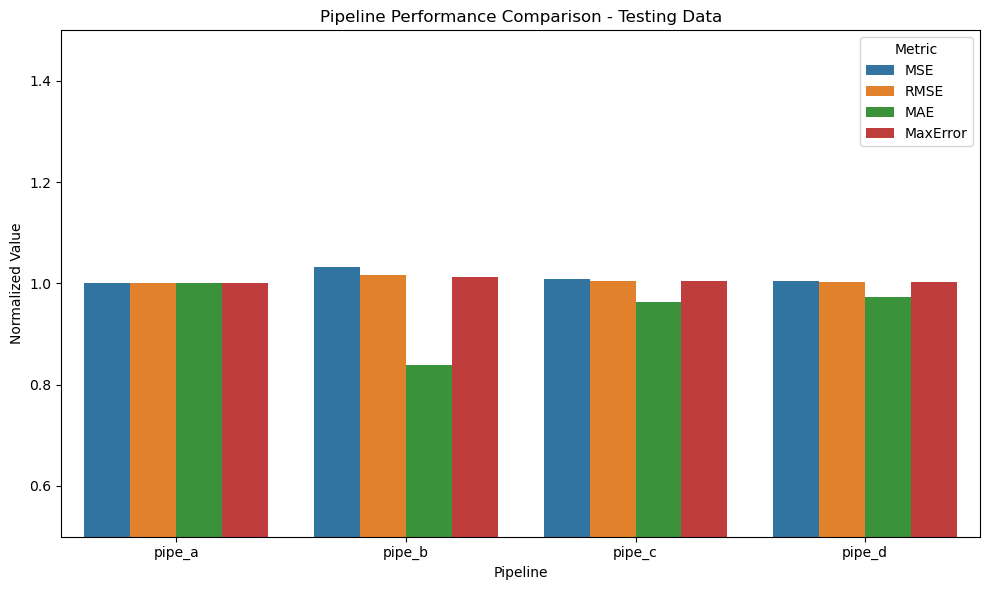

In [315]:
### >>> bar plot seaborn <<< ###
### >>> 1. plot the testing data result
# melt data into long format (Seaborn likes this)
df_long = df_norm.melt(id_vars='pipeline', 
                       value_vars=['MSE','RMSE','MAE','MaxError'], 
                       var_name='Metric', value_name='Normalized Value')

# plot
fig, ax = plt.subplots(figsize=(10,6)) # create a fig obejct
# plt.figure(figsize=(10,6))
sns.barplot(data=df_long, x='pipeline', y='Normalized Value', hue='Metric')

# zoom in y-axis
plt.ylim(0.5, 1.5)

plt.title('Pipeline Performance Comparison - Testing Data')
plt.ylabel('Normalized Value')
plt.xlabel('Pipeline')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()
fig.savefig('Pipeline_test_cmpr_03.png', dpi=300, bbox_inches='tight')


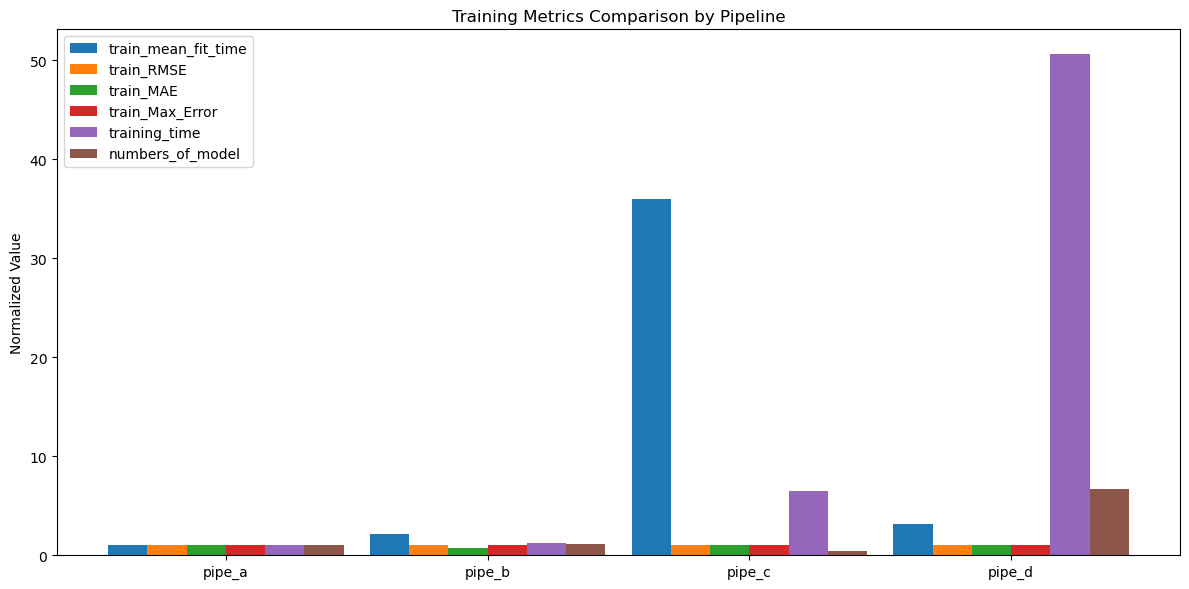

In [316]:
### >>> 2. plot the training data evaluation
plot_cols = ['train_mean_fit_time', 'train_RMSE', 'train_MAE', 'train_Max_Error', 'training_time', 'numbers_of_model']

# Subset of data
df_plot = df_norm[plot_cols].copy()
pipelines = df_norm['pipeline']

# Set up bar positions
x = np.arange(len(pipelines))
width = 0.15  # width of each bar

fig, ax = plt.subplots(figsize=(12,6))

for i, col in enumerate(plot_cols):
    ax.bar(x + i*width, df_plot[col], width=width, label=col)

ax.set_xticks(x + width*(len(plot_cols)-1)/2)
ax.set_xticklabels(pipelines)
ax.set_ylabel('Normalized Value')
ax.set_title('Training Metrics Comparison by Pipeline')
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig('Training_metrics_cmpar_03.png')

/tmp/ipykernel_9489/3589378759.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_9489/3589378759.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_9489/3589378759.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_9489/3589378759.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


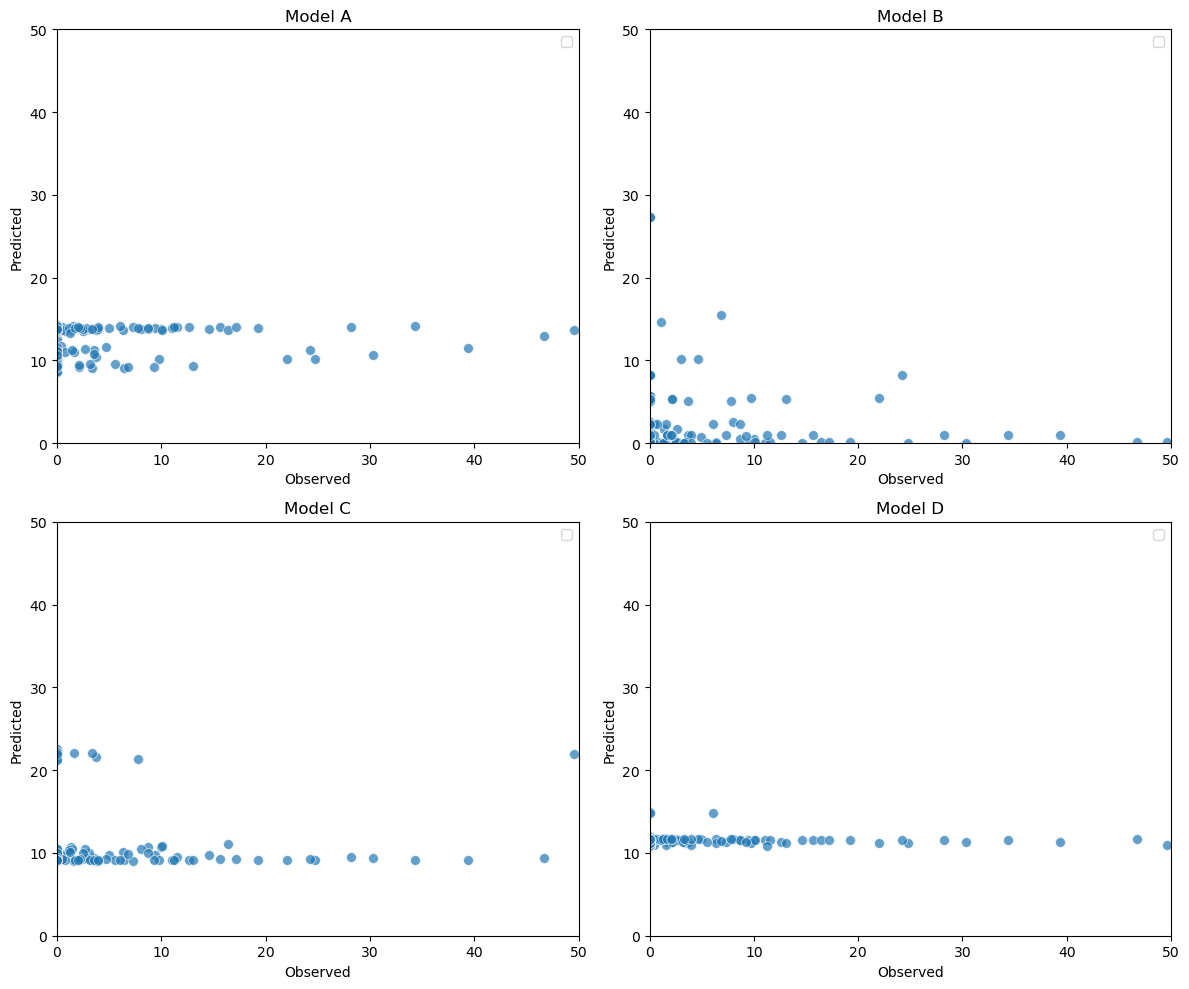

In [317]:


# Example: your 4 DataFrames
dfs = {
    "Model A": output_a,
    "Model B": output_b,
    "Model C": output_c,
    "Model D": output_d
}

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # flatten to 1D list for easy looping

# Loop through DataFrames and plot
for ax, (title, df) in zip(axes, dfs.items()):
    sns.scatterplot(data=df, x='Observed', y='Predicted', ax=ax, s=50, alpha=0.7)
    # sns.lineplot(x=df['Observed'], y=df['Observed'], ax=ax, color='red', linestyle='--', label='Ideal')  # reference line
    
    ax.set_xlim(0, 50)   # adjust as needed
    ax.set_ylim(0, 50)
    
    ax.set_title(title)
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
    ax.legend()


# Adjust layout
plt.tight_layout()
plt.show()


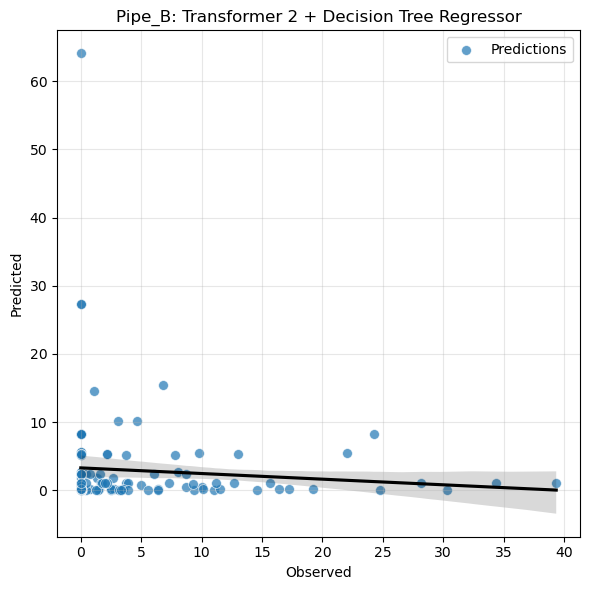

In [318]:
### Plot Observed vs Predict for Pipeine B

# Step 1: trim top/bottom 5% (keep 90% in the middle)
lower, upper = output_b['Observed'].quantile([0, 0.95])
df_plot = output_b[(output_b['Observed'] >= lower) & (output_b['Observed'] <= upper)]

# Step 2: plot with Seaborn
plt.figure(figsize=(6, 6))

# --- Scatter (your predicted vs observed) ---
sns.scatterplot(data=df_plot, x='Observed', y='Predicted', s=50, alpha=0.7, label='Predictions')

# --- OLS regression line (trend line for diagnostic) ---
sns.regplot(data=df_plot, x='Observed', y='Predicted',
            scatter=False,  # don't plot scatter again
            line_kws={'color':'black', 'label':'OLS fit'}
)

# --- Ideal y=x line using Seaborn lineplot ---
x_range = np.linspace(df_plot['Observed'].min(), df_plot['Observed'].max(), 200)
# sns.lineplot(x=x_range, y=x_range, color='red', linestyle='--', label='Ideal y=x')

# plt.xlim(0,100)
# plt.ylim(0,100)

plt.title("Pipe_B: Transformer 2 + Decision Tree Regressor")
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


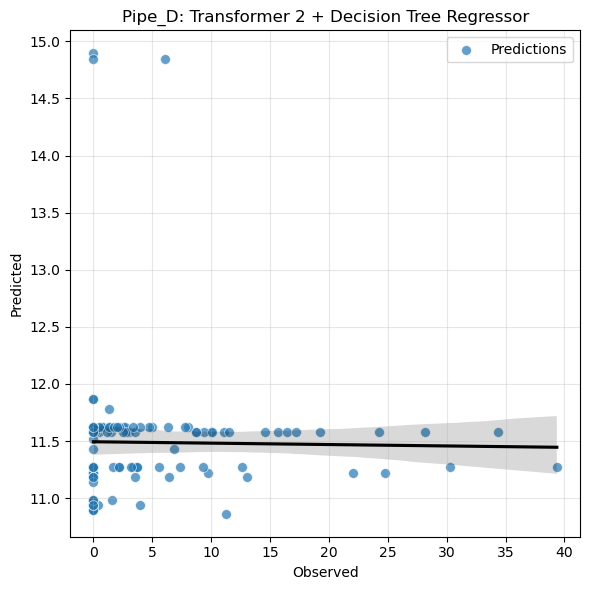

In [319]:
### Plot Observed vs Predict for Pipeine D

# Step 1: trim top/bottom 5% (keep 90% in the middle)
lower, upper = output_d['Observed'].quantile([0, 0.95])
df_plot = output_d[(output_d['Observed'] >= lower) & (output_d['Observed'] <= upper)]

# Step 2: plot with Seaborn
plt.figure(figsize=(6, 6))

# --- Scatter (your predicted vs observed) ---
sns.scatterplot(data=df_plot, x='Observed', y='Predicted', s=50, alpha=0.7, label='Predictions')

# --- OLS regression line (trend line for diagnostic) ---
sns.regplot(data=df_plot, x='Observed', y='Predicted',
            scatter=False,  # don't plot scatter again
            line_kws={'color':'black', 'label':'OLS fit'}
)

# --- Ideal y=x line using Seaborn lineplot ---
x_range = np.linspace(df_plot['Observed'].min(), df_plot['Observed'].max(), 200)
# sns.lineplot(x=x_range, y=x_range, color='red', linestyle='--', label='Ideal y=x')

# plt.xlim(0,100)
# plt.ylim(0,100)

plt.title("Pipe_D: Transformer 2 + Decision Tree Regressor")
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Evaluate

Which model has the best performance?

**`Answer`**: A total of three random runs were executed to evaluate the performance of four different pipelines. The scoring matrix applied here are: RMSE, MAE, and Max_Error.

**Runs:** 
- Run 1, pipeline(random_state=51), train_test_split(random_state = 123) 
- Run 2, pipeline(random_state=111), train_test_split(random_state = 79)
- Run 3, pipeline(random_state=9), train_test_split(random_state = 891) (the last one show here)

**Transformers:**
- transformer 1 = Standard + OneHot 
- transformer 2 = Standard + Power + OneHot

- Pipe_A (baseline): Transformer 1 + PCA + KNN Regressor  
- Pipe_B: Transformer 2 + Decision Tree Regressor
- Pipe_C: Transformer 1 + Bagging
- Pipe_D: Transformer 2 + XGBoost


Based on the normalize result from both training and testing data against the baseline(Pipeline_A), **Pipeline B** demonstrates a promising reduction in MAE by approximately **20%**, albeit with a slight adverse effect on MSE, RMSE, and Max Error. **Pipeline D** achieves a modest improvement of around 2% in RMSE compared to the baseline. (**Pipeline A**) 

⚠️ When examining the **RMSE/MAE**, Pipeline B has a value 1.29, indicating that while average errors are lower, *some predictions deviate much more than others*. Further examining and comparing the Observed vs Predicted of Pipeline Band Pipeline D also confirm this finding.  This is because **MAE treats all errors equally and its calculation doesn’t penalize outliers, whereas RMSE does**. When weighting the stability and the accuracy, **Pipeline D** offers a more consistent performance overall. However, further improvement on the training efficiency is crucial for its application.  

![image](images/final_summary.png)


### Experiment Tracking Note

- Run 1, pipeline(random_state=51), train_test_split(random_state = 123) 

- Run 2, pipeline(random_state=111), train_test_split(random_state = 79)

- Run 3, pipeline(random_state=9), train_test_split(random_state = 891), last one show here

# Export

+ Save the best performing model to a pickle file.

In [320]:
pipe_d

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('std_scaler',
                                                  StandardScaler(),
                                                  Index(['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain'], dtype='object')),
                                                 ('num_yj', PowerTransformer(),
                                                  ['ffmc', 'dc', 'isi', 'rh',
                                                   'rain']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  Index(['coord_x', 'coord_y', 'day', 'month'], dtype='object'))]))...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=9, ...))])

In [321]:
import pickle

# Save pipe_b
with open('forest_fire_XGBoost.pkl', 'wb') as f:
    pickle.dump(pipe_d, f)

In [322]:
# # Load
with open('forest_fire_XGBoost.pkl', 'rb') as f:
    pipe_d = pickle.load(f)

In [323]:
pipe_d.named_steps

{'preproc': ColumnTransformer(transformers=[('std_scaler', StandardScaler(),
                                  Index(['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain'], dtype='object')),
                                 ('num_yj', PowerTransformer(),
                                  ['ffmc', 'dc', 'isi', 'rh', 'rain']),
                                 ('onehot',
                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                  Index(['coord_x', 'coord_y', 'day', 'month'], dtype='object'))]),
 'xgb': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
         

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [324]:
pipe_d.named_steps

{'preproc': ColumnTransformer(transformers=[('std_scaler', StandardScaler(),
                                  Index(['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain'], dtype='object')),
                                 ('num_yj', PowerTransformer(),
                                  ['ffmc', 'dc', 'isi', 'rh', 'rain']),
                                 ('onehot',
                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                  Index(['coord_x', 'coord_y', 'day', 'month'], dtype='object'))]),
 'xgb': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
         

In [325]:
import shap


In [326]:
pipe_d.fit(X_train,Y_train)

data_transform = pipe_d.named_steps['preproc'].transform(X_test)

explainer = shap.TreeExplainer(
    pipe_d.named_steps['xgb'], 
    data_transform,
    feature_names = pipe_d.named_steps['preproc'].get_feature_names_out())

shap_values = explainer(data_transform)

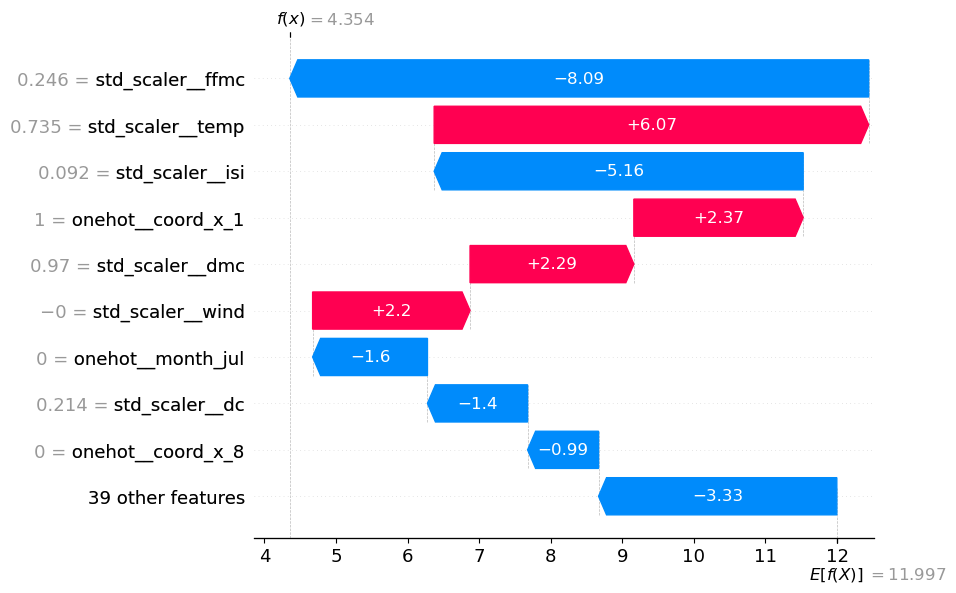

In [327]:
shap.plots.waterfall(shap_values[1])

**`Answer`**: 

1. The selected model is Pipeline D: Transformer 2 = Standard + Power + OneHot + XGBoost. Based on the SHAP graph, some observations are shown below:  

    - **ffmc (FFMC)**: Fine Fuel Moisture Code, which measures the moisture content of fine surface fuels. Lower values reduce the likelihood of fire spread --> Make Sense ✅  

    - **Temp**: Temperature, higher values increase fire area --> Make Sense ✅  

    - **isi (ISI)**: Initial Spread Index. Lower values reduce the likelihood of fire spreaad --> Make Sense ✅

    - **onehot_cord_x_1**: SHAP shows positive contribution, but this is inconsistent with other locations (e.g., X=8 or 9 also have large fire areas) --> ❌ Not fully interpretable.

    - dmc (Drought Code): Higher values will likely contribute to increase fire area. --> Make Sense ✅

2. **Recommandation**: 
    - Drop or reduce some of all categorical variables (map locations, month, etc.) as they don't represent controllable drivers, despite that they could be useful for pattern.

    - Remove the outlier of the fire area 1090 to reduce skewness and improve model training stability.

/home/yikai/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


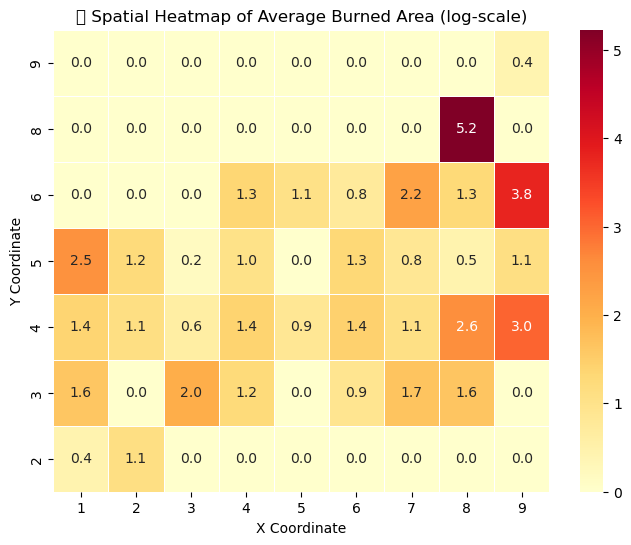

In [328]:
# 💾 Load your dataset (adjust path)
df = fires_dt

# 🧹 Optional: log-transform the burned area for better visibility
df["log_area"] = np.log1p(df["area"])  # log(area + 1)

# 📊 Create pivot table for spatial heatmap
pivot = df.pivot_table(
    values="log_area",  # or "area" if you prefer raw values
    index="coord_y",
    columns="coord_x",
    aggfunc="mean",      # average log-area burned per (X,Y) cell
    fill_value=0
)

# 🎨 Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.5, annot=True, fmt=".1f")
plt.title("🔥 Spatial Heatmap of Average Burned Area (log-scale)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.gca().invert_yaxis()  # so (1,1) starts at bottom-left
plt.show()


## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.